In [1]:
# !pip install adjustText  -- 필요 시 주석 해제 후 사용

from __future__ import annotations

from pathlib import Path
import os
import warnings
import requests
import seaborn as sns

import pandas as pd
import numpy as np
import re

import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point
import folium

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from typing import Optional, Tuple, Dict
from datetime import datetime
from matplotlib.ticker import FuncFormatter
from adjustText import adjust_text 
from matplotlib.ticker import PercentFormatter
from shapely import wkt


warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.2f}'.format

# 한글 및 마이너스 깨짐 방지
try:
    mpl.rcParams["font.family"] = "Malgun Gothic"   # Windows
except:
    mpl.rcParams["font.family"] = "AppleGothic"    # Mac

mpl.rcParams["axes.unicode_minus"] = False

%config InlineBackend.figure_format = 'retina'

# 키워드별 언급량

In [2]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "완전최종_전처리완료_CSV모음")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "키워드별_언급량.csv")

keyword = pd.read_csv(DATA_DIR)

keyword

,기준년월,연도,월,키워드,언급량,월별순위
0,202501,2025,1,K-Culture 관련 거리,881,6
1,202501,2025,1,K-공연관람,39519,1
2,202501,2025,1,K-굿즈,128,8
3,202501,2025,1,K-댄스 배우기,4135,5
4,202501,2025,1,K-덕질,8211,2
...,...,...,...,...,...,...
115,202512,2025,12,K-드라마/영화 관련 대상지,6161,3
116,202512,2025,12,K-예능 대상지,230,8
117,202512,2025,12,K-팝업 스토어,48,10
118,202512,2025,12,엔터테인먼트 방문(HYBE_ SM_ JYP),886,5


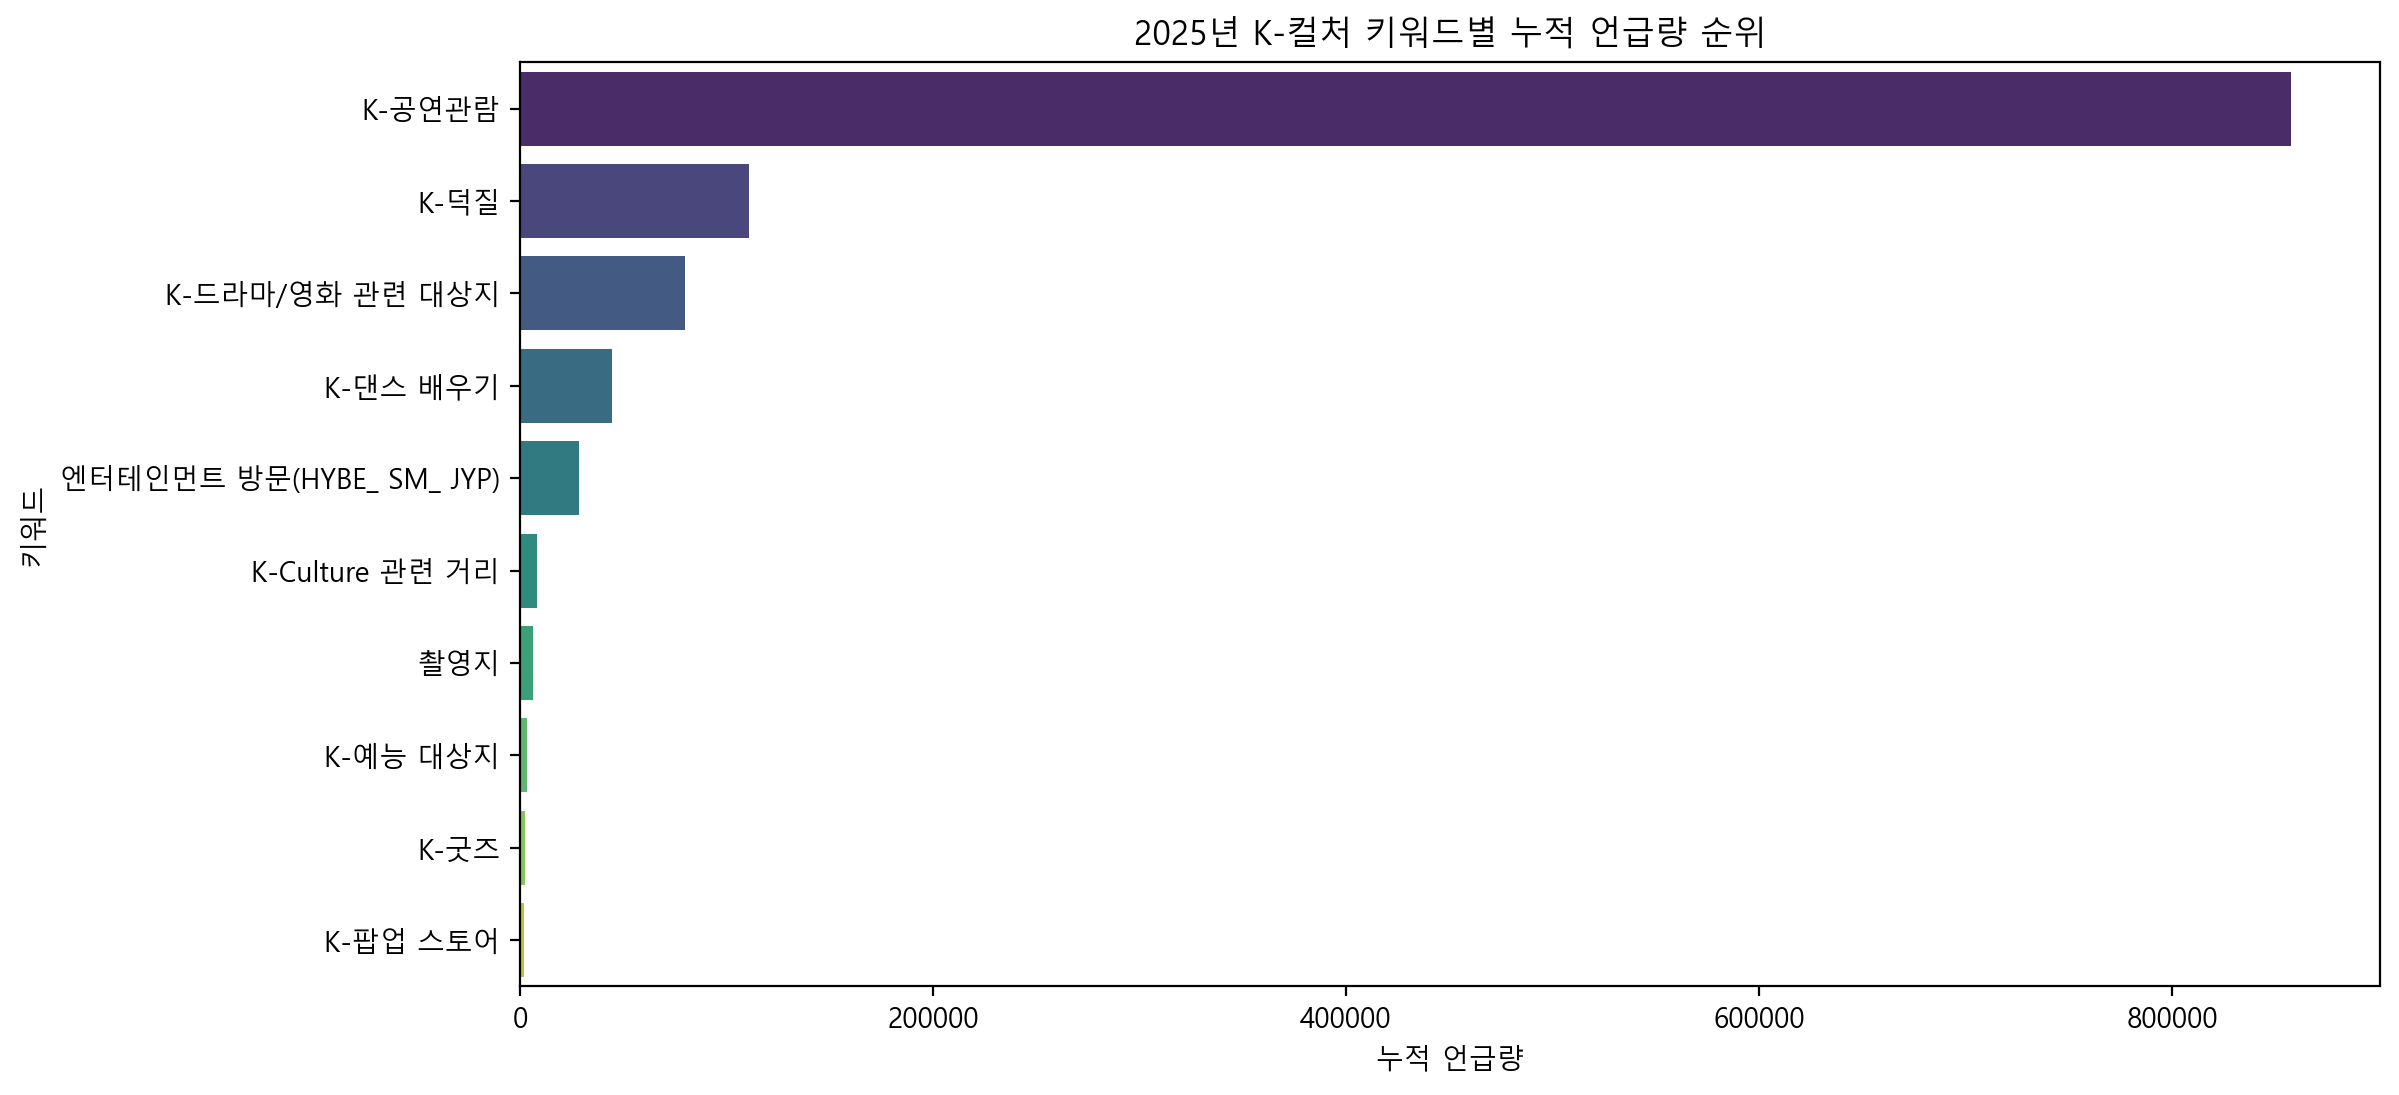

In [3]:
# 1. 키워드별 전체 언급량 합계 계산 및 내림차순 정렬
total_keywords = keyword.groupby('키워드')['언급량'].sum().sort_values(ascending=False).reset_index()

# 2. 막대 그래프 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=total_keywords, x='언급량', y='키워드', palette='viridis')
plt.title('2025년 K-컬처 키워드별 누적 언급량 순위')
plt.xlabel('누적 언급량')
plt.ylabel('키워드')
plt.show()

In [4]:
total_keywords

,키워드,언급량
0,K-공연관람,857834
1,K-덕질,111169
2,K-드라마/영화 관련 대상지,79914
3,K-댄스 배우기,44617
4,엔터테인먼트 방문(HYBE_ SM_ JYP),28798
5,K-Culture 관련 거리,8267
6,촬영지,6117
7,K-예능 대상지,3638
8,K-굿즈,2600
9,K-팝업 스토어,2087


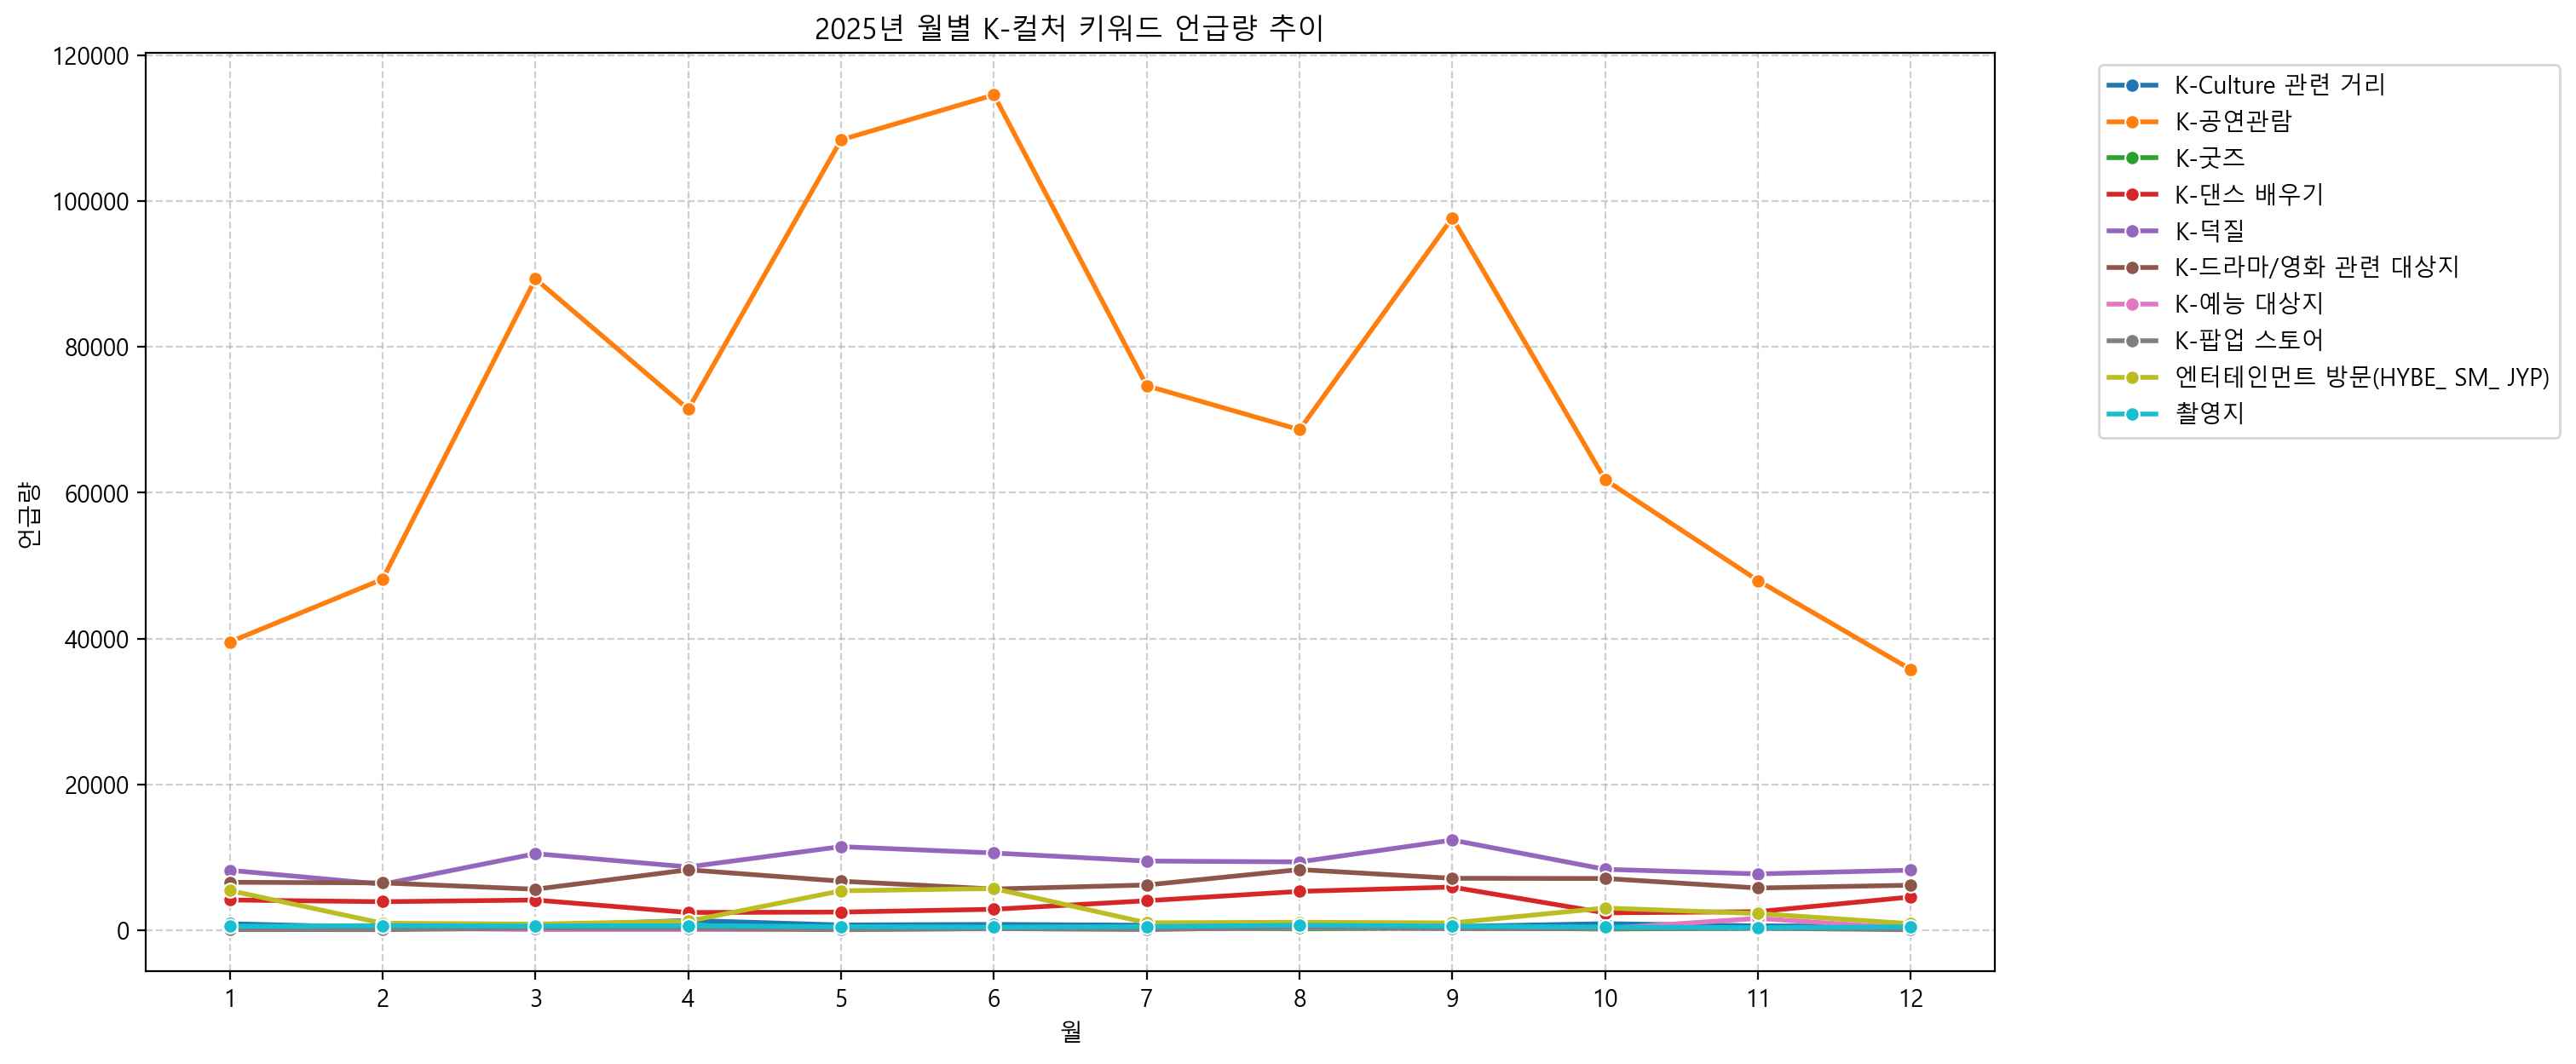

In [5]:
plt.figure(figsize=(14, 7))
# 월별 변화를 선 그래프로 시각화 (hue를 키워드로 지정하여 색상 구분)
sns.lineplot(data=keyword, x='월', y='언급량', hue='키워드', marker='o', linewidth=2)

plt.title('2025년 월별 K-컬처 키워드 언급량 추이')
plt.xlabel('월')
plt.ylabel('언급량')
plt.xticks(range(1, 13)) # x축을 1~12월로 고정
# 범례가 그래프를 가리지 않도록 바깥으로 빼주기
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

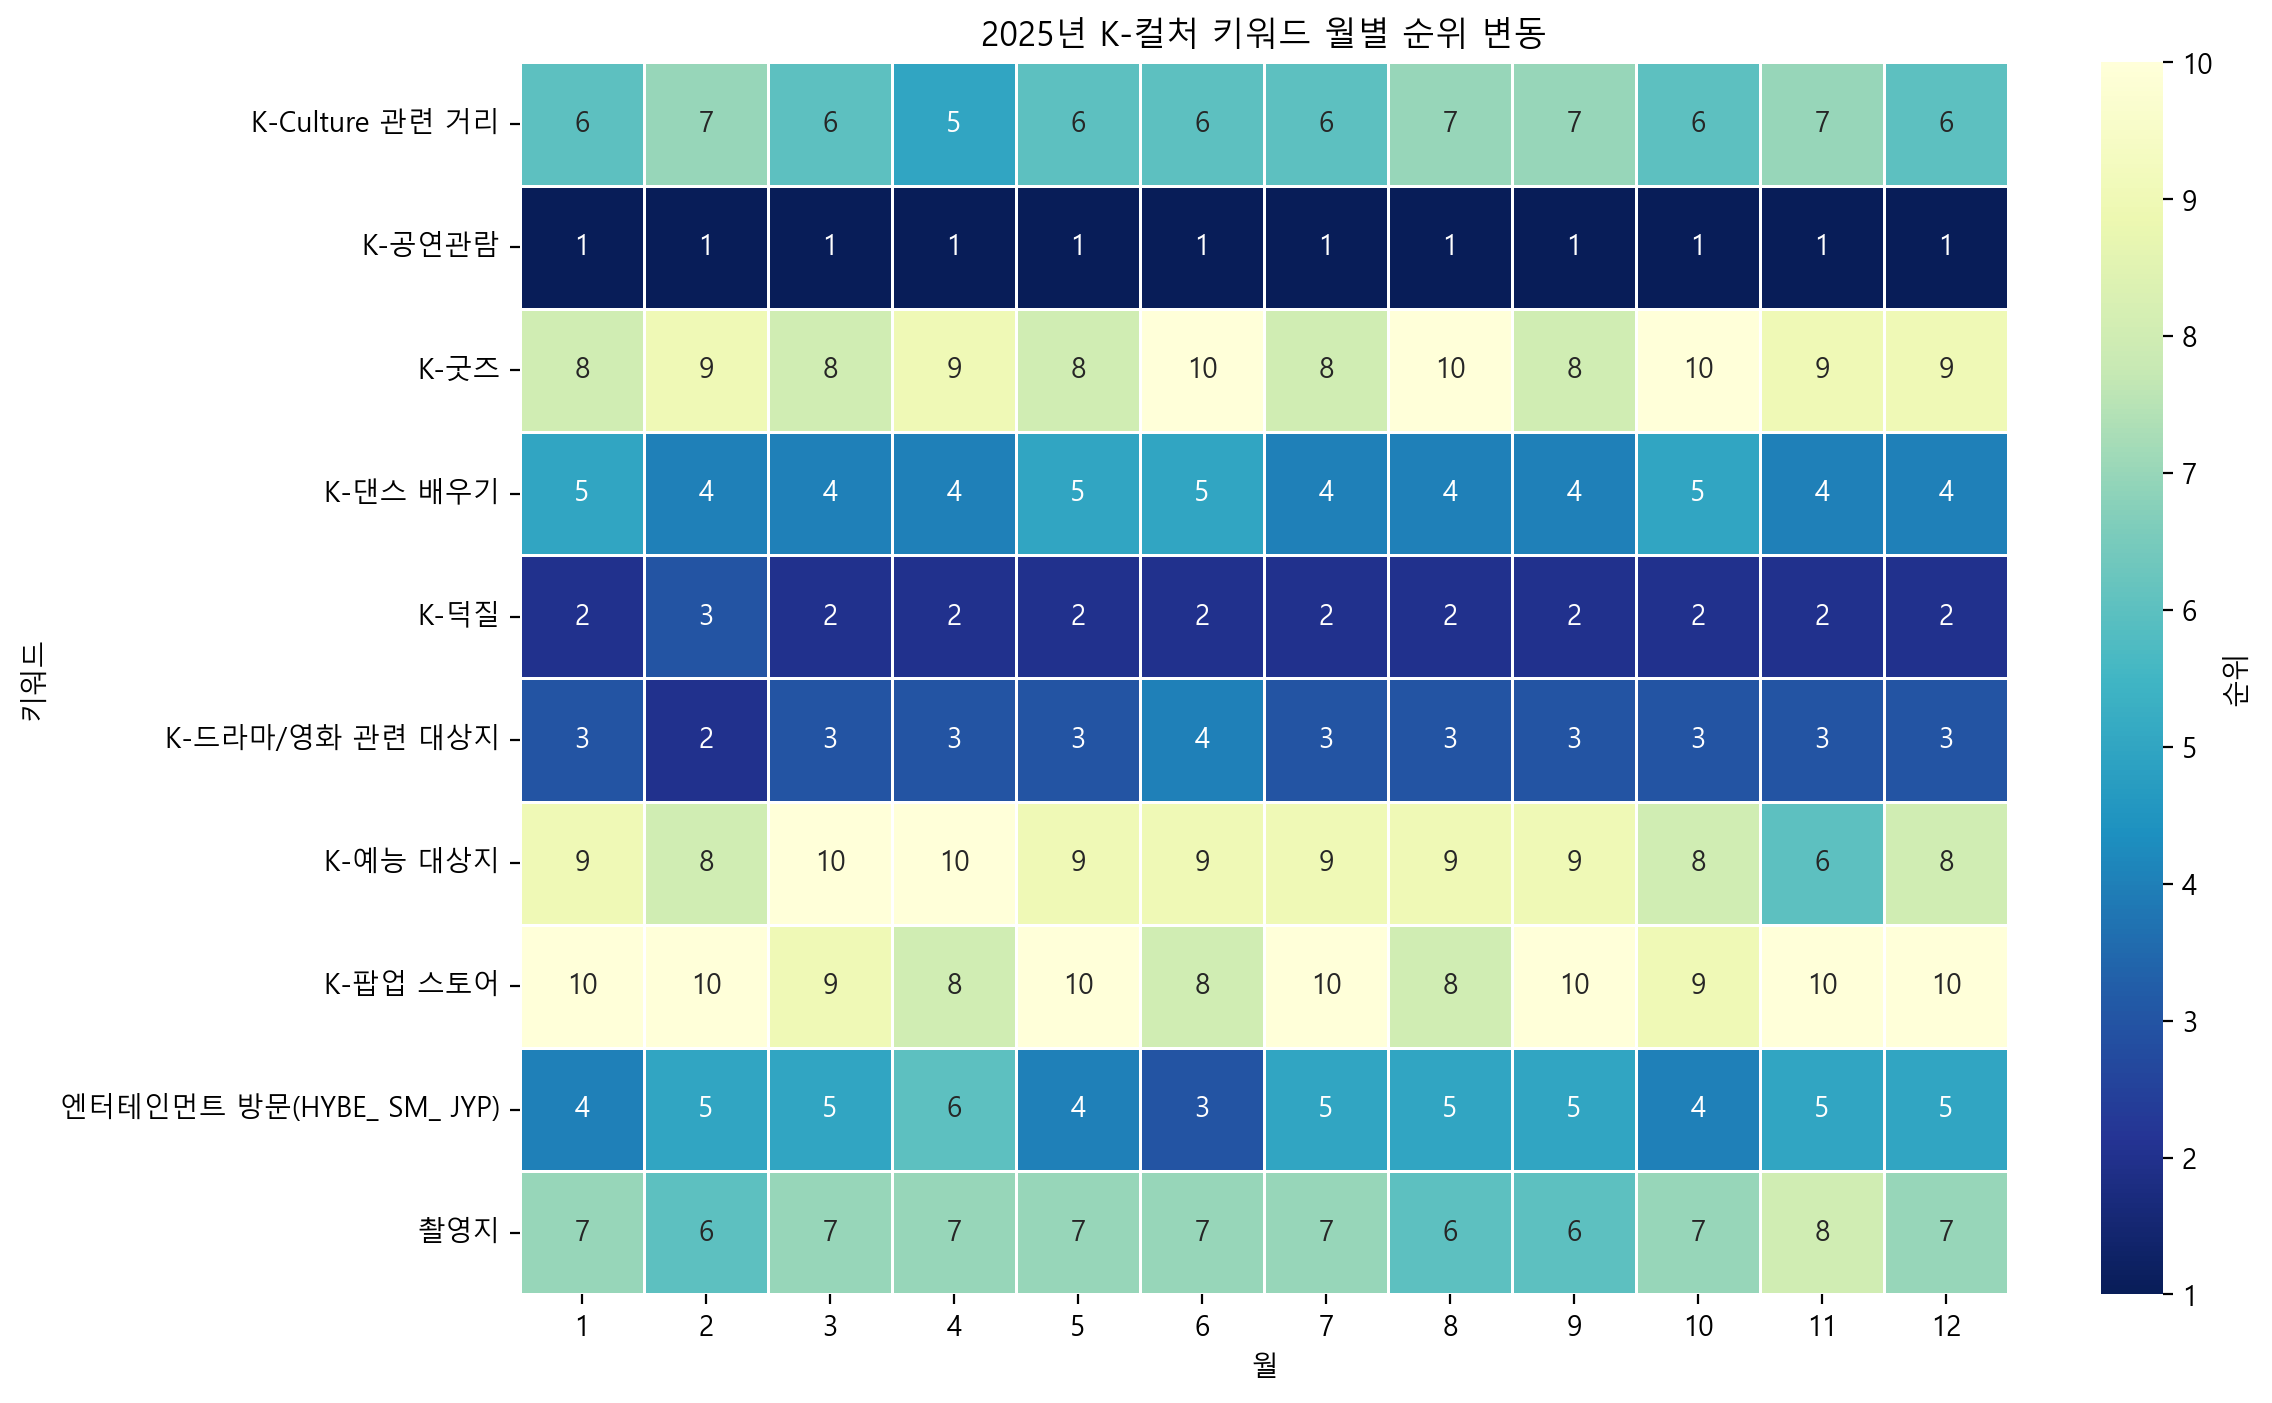

In [6]:
# 1. 월을 열(Column)로, 키워드를 행(Row)으로 하는 피벗 테이블 생성 (값은 '월별순위')
rank_pivot = keyword.pivot(index='키워드', columns='월', values='월별순위')

# 2. 히트맵 시각화
plt.figure(figsize=(12, 8))
# 순위는 숫자가 작을수록(1위) 높은 것이므로 _r이 붙은 색상표(역순)를 사용합니다.
sns.heatmap(rank_pivot, annot=True, fmt=".0f", cmap='YlGnBu_r', linewidths=0.5, cbar_kws={'label': '순위'})

plt.title('2025년 K-컬처 키워드 월별 순위 변동')
plt.xlabel('월')
plt.ylabel('키워드')
plt.show()

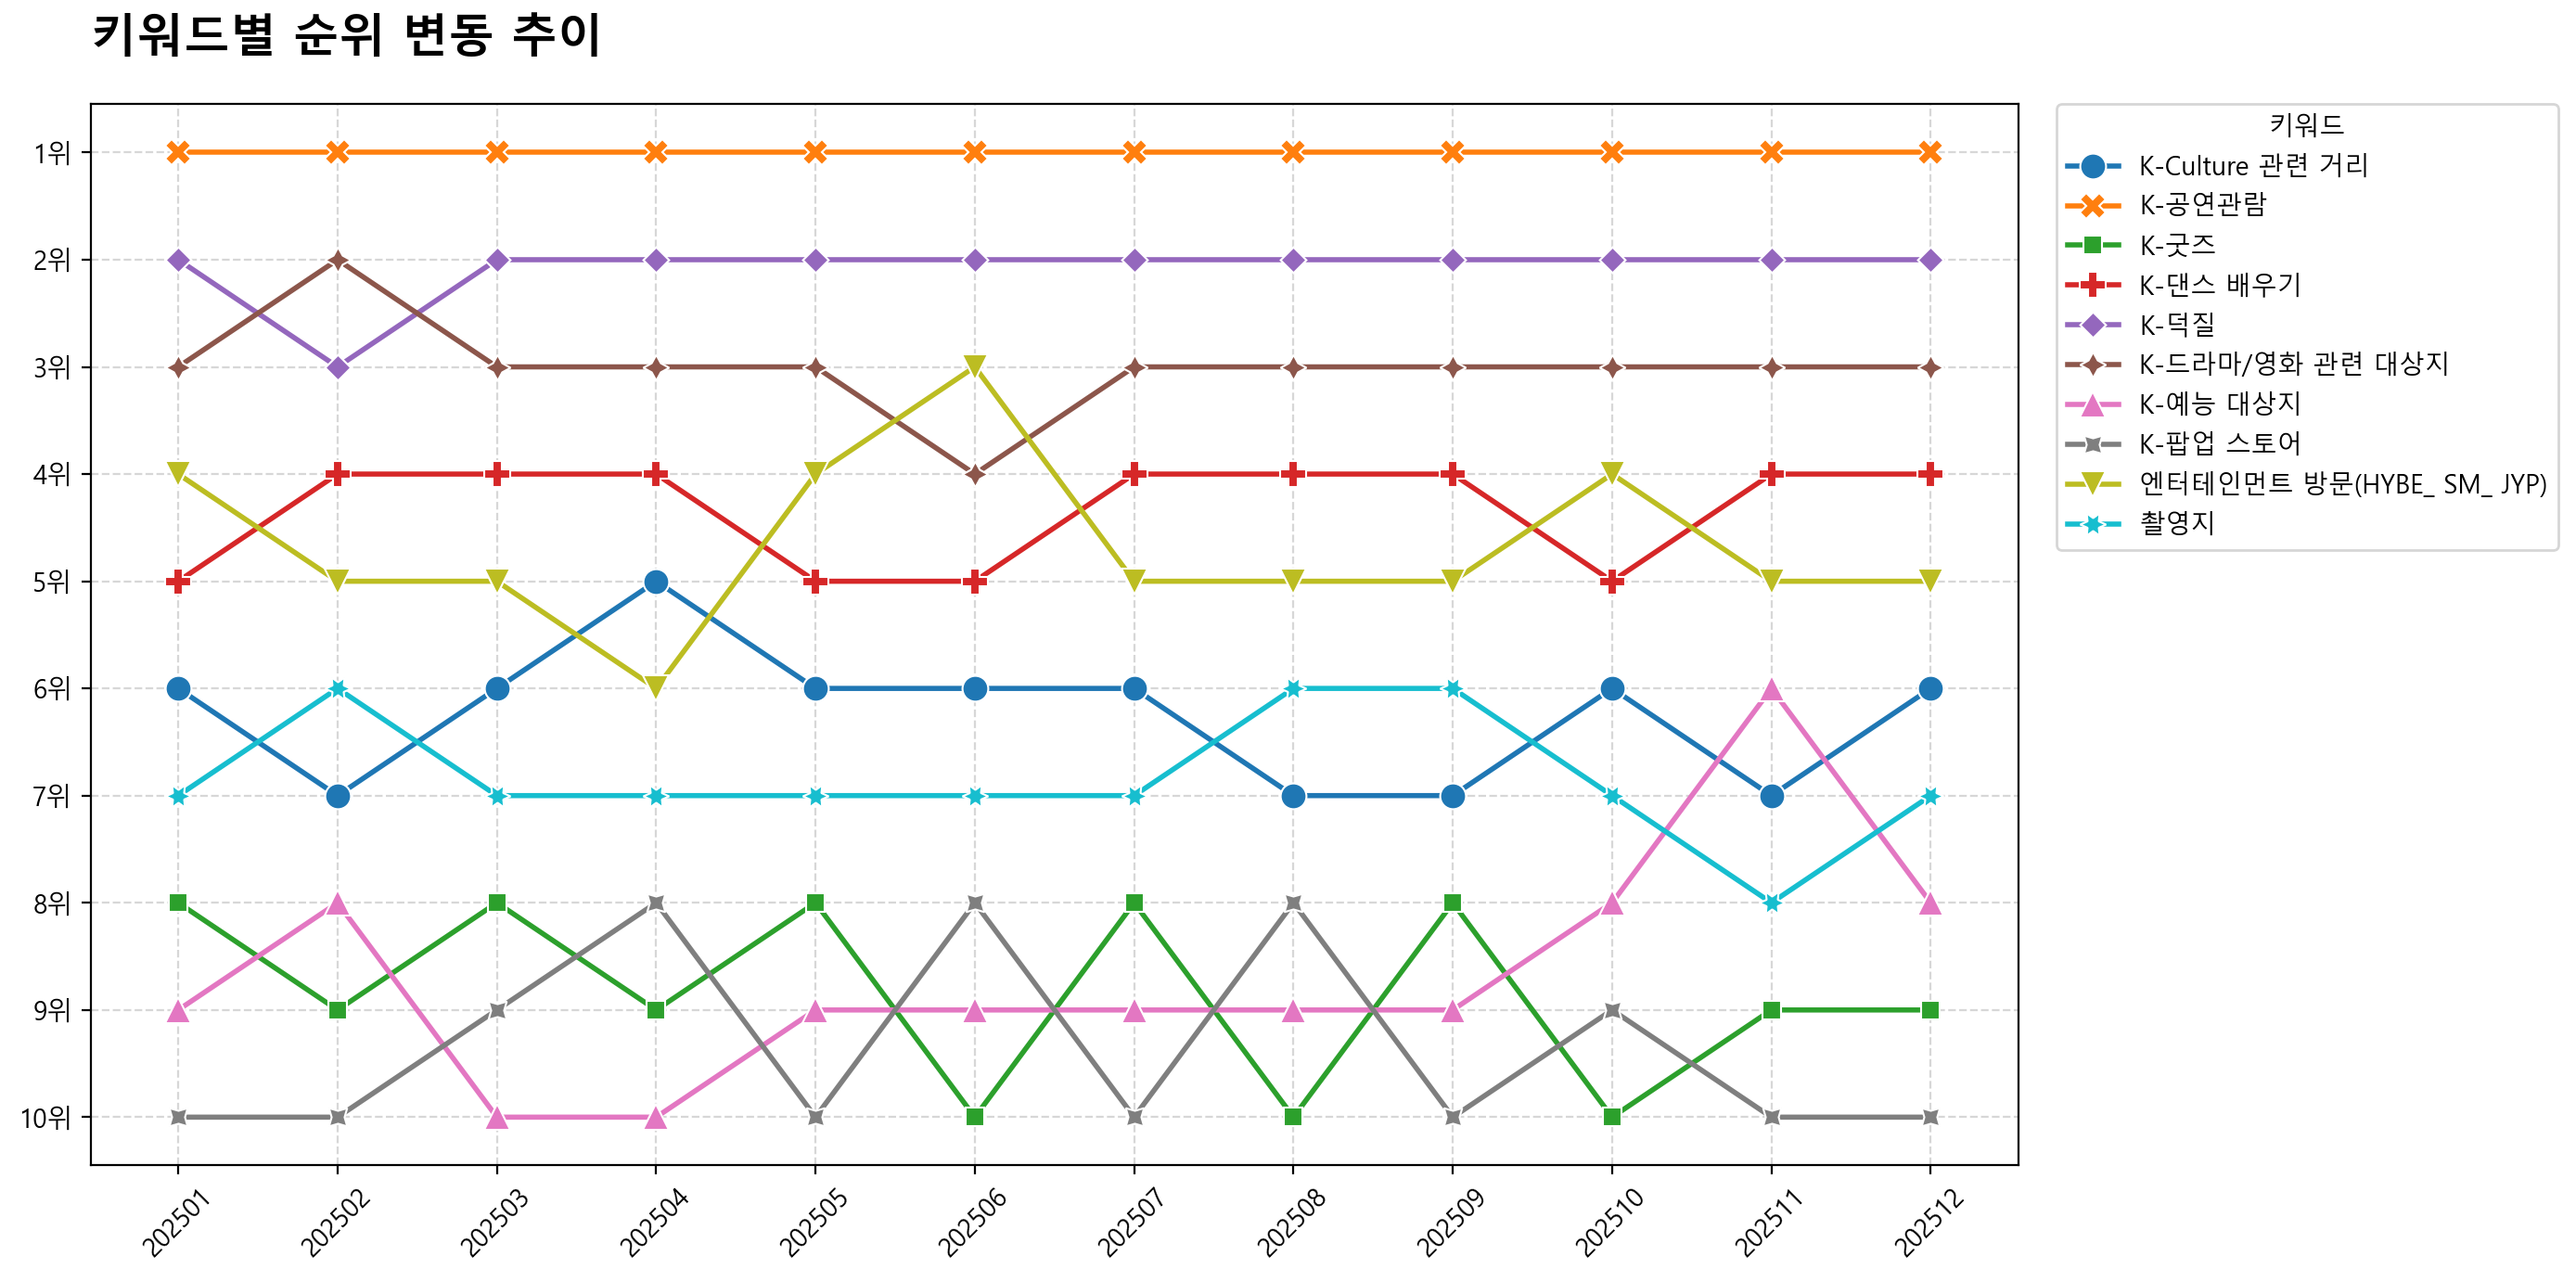

In [7]:
# '기준년월'을 문자열(String)로 변환
keyword['기준년월'] = keyword['기준년월'].astype(str)

# 그래프 사이즈 설정
plt.figure(figsize=(14, 7))

# Seaborn으로 라인 그래프 그리기
sns.lineplot(data=keyword, 
             x='기준년월', 
             y='월별순위', 
             hue='키워드', 
             style='키워드', 
             markers=True, 
             dashes=False, 
             palette='tab10',
             linewidth=2, 
             markersize=10)

# Y축 뒤집기 (1위가 맨 위로 오도록)
plt.gca().invert_yaxis()

#  Y축 눈금(Tick)을 1위부터 10위까지 정수로 설정
plt.yticks(range(1, 11), [f'{i}위' for i in range(1, 11)])

# 제목 및 축 라벨 설정
plt.title('키워드별 순위 변동 추이', fontsize=18, fontweight='bold', loc='left', pad=20)
plt.xlabel('') # X축 라벨 숨김 (기준년월이 직관적이므로)
plt.ylabel('') # Y축 라벨 숨김

# X축 글자 살짝 기울이기
plt.xticks(rotation=45)

# 배경 그리드(격자) 추가
plt.grid(True, axis='both', linestyle='--', alpha=0.5)

# 범례(Legend)를 그래프 오른쪽 밖으로 빼기
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title='키워드')

plt.tight_layout()
plt.show()

# 언급량 인게이지먼트

## 언급량 인게이지먼트 추이

In [8]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "완전최종_전처리완료_CSV모음")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "한국관광관련_언급량_인게이지먼트_추이.csv")

mention = pd.read_csv(DATA_DIR)

mention

,기준년월,연도,월,국가,긍정언급량 비율,부정언급량 비율,언급량,인게이지먼트,언급량 증감률,인게이지먼트 증감률
0,202501,2025,1,글로벌,81.05,18.95,560828,7852508,-20.57,-14.63
1,202502,2025,2,글로벌,88.41,11.59,589905,7071237,5.18,-9.95
2,202503,2025,3,글로벌,79.44,20.56,851707,7049352,44.38,-0.31
3,202504,2025,4,글로벌,75.00,25.00,602954,7586380,-29.21,7.62
4,202505,2025,5,글로벌,81.91,18.09,805140,13443975,33.53,77.21
5,202506,2025,6,글로벌,82.70,17.30,717642,11827913,-10.87,-12.02
6,202507,2025,7,글로벌,77.87,22.13,677469,12528290,-5.60,5.92
7,202508,2025,8,글로벌,76.67,23.33,677389,13634079,-0.01,8.83
8,202509,2025,9,글로벌,78.98,21.02,760099,13280218,12.21,-2.60
9,202510,2025,10,글로벌,72.29,27.71,681177,19147911,-10.38,44.18


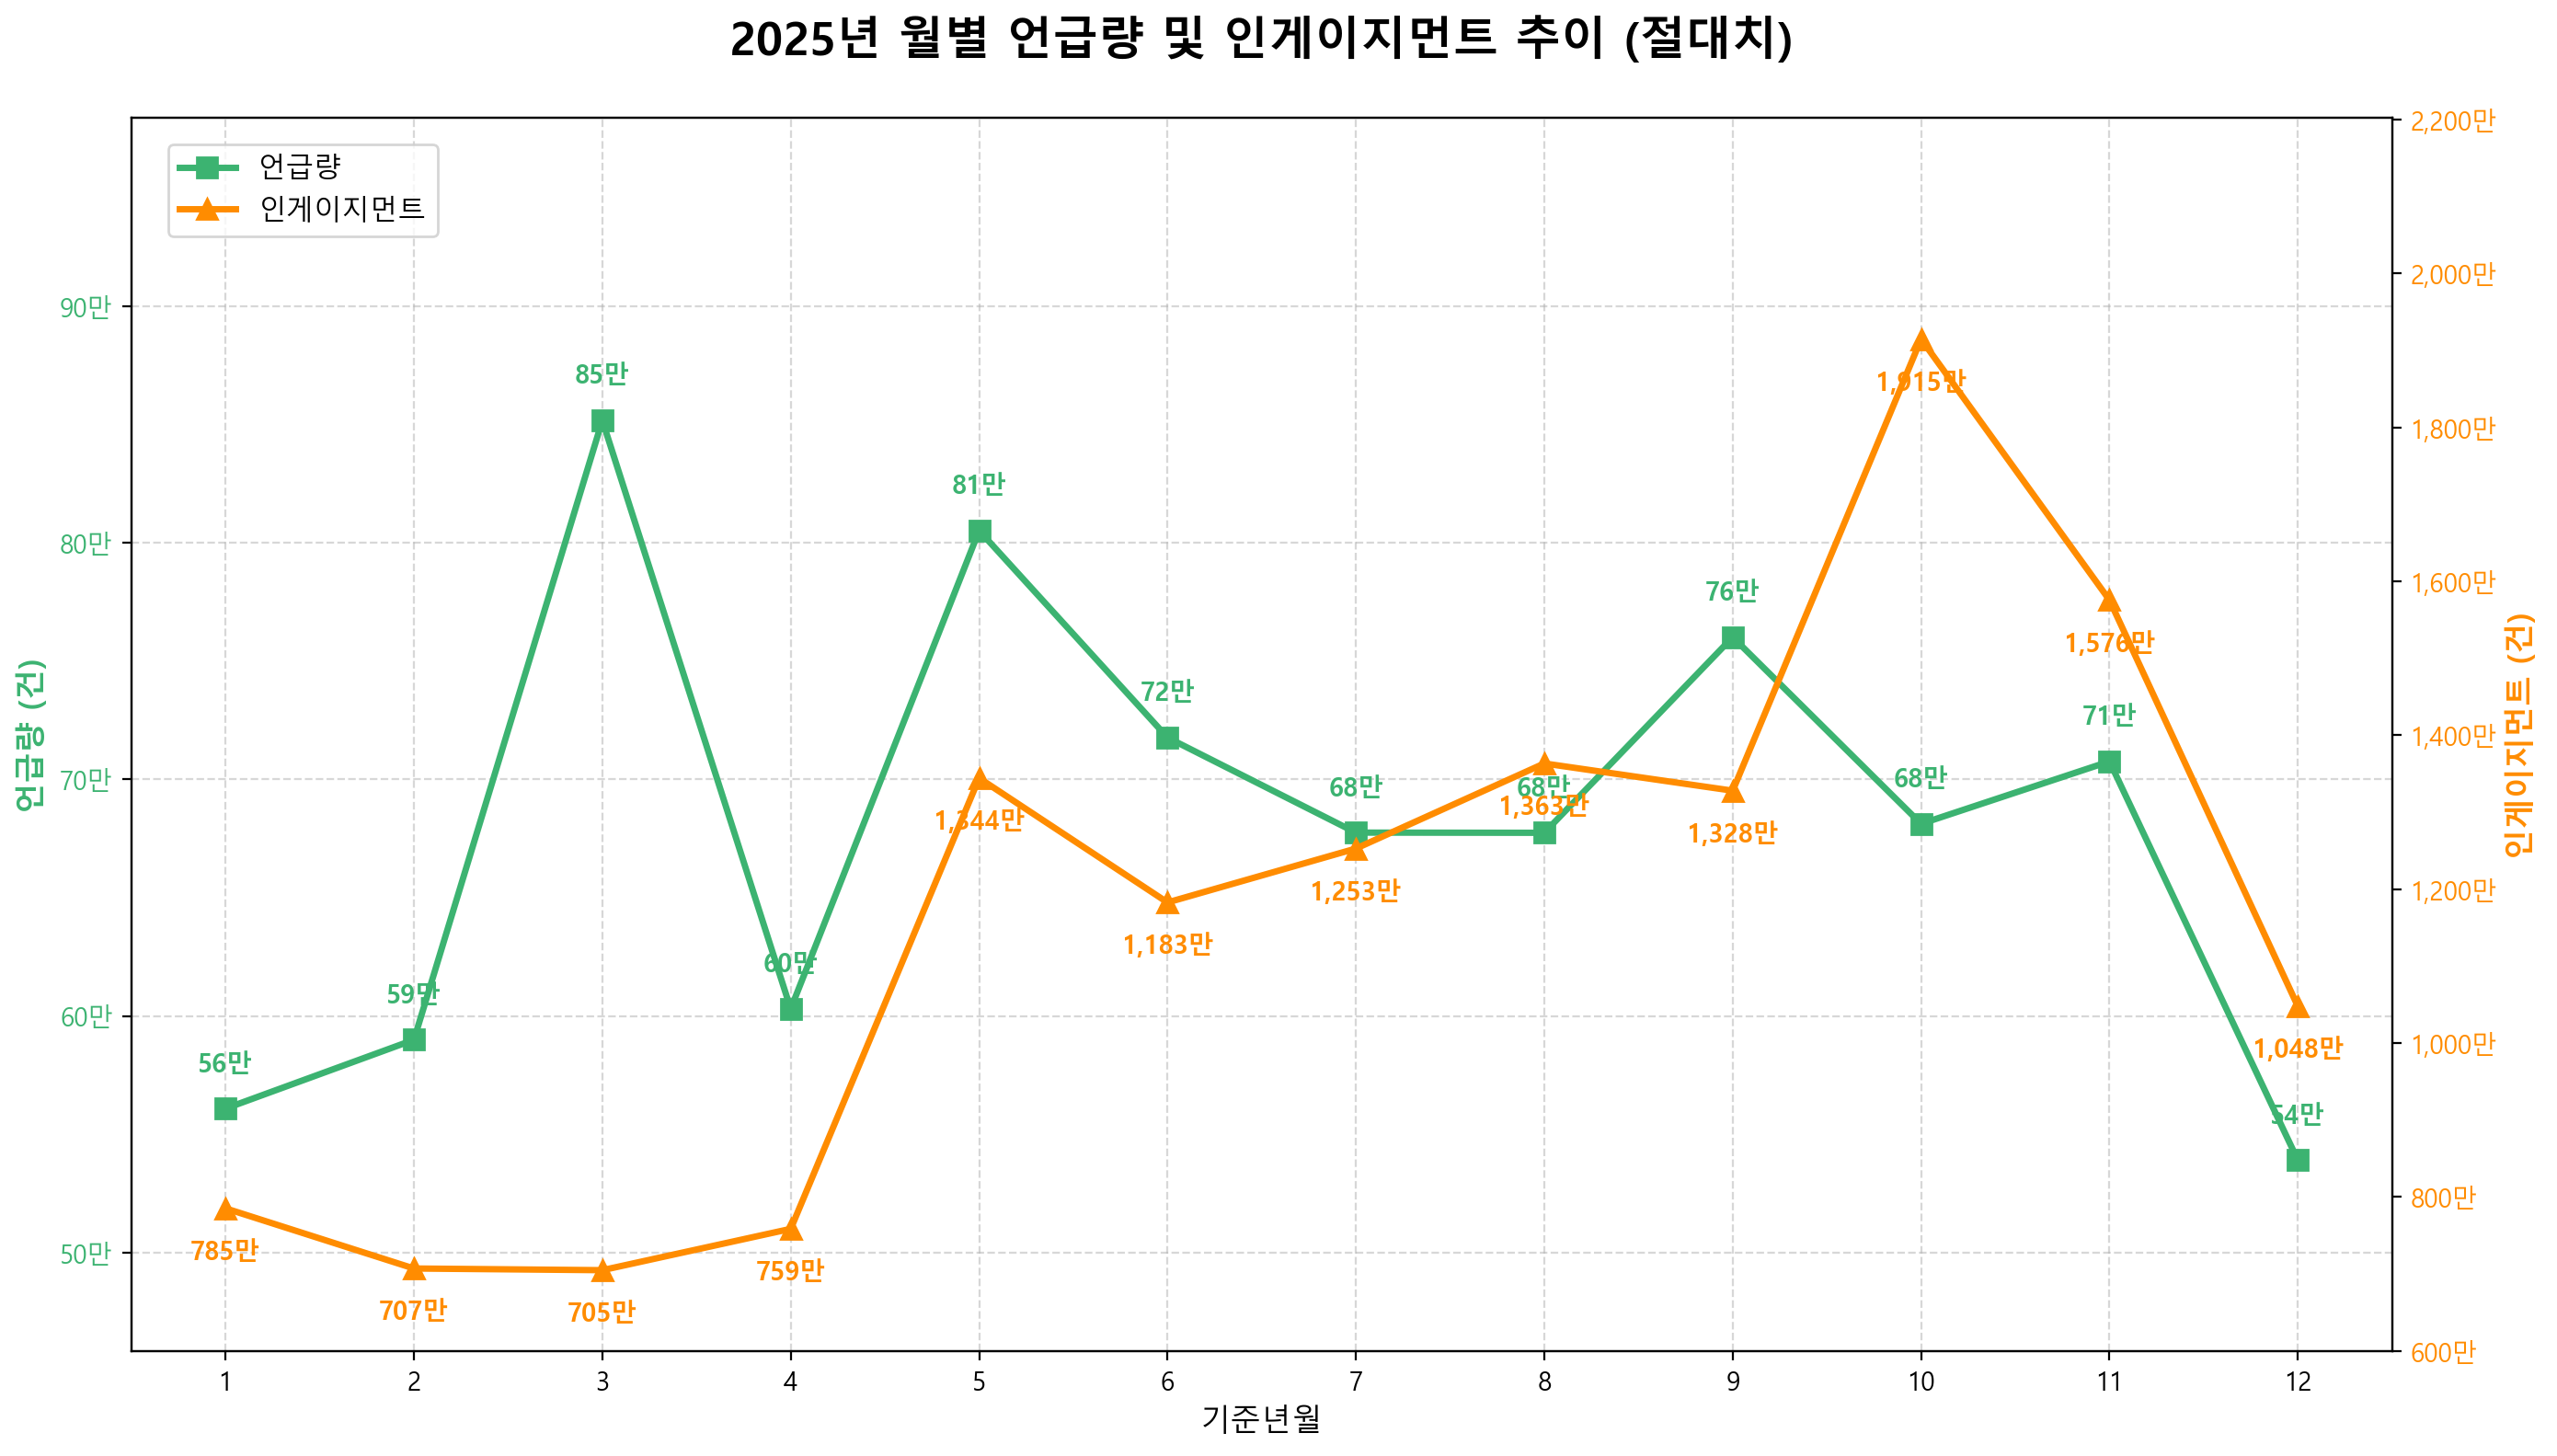

In [9]:
# X축을 문자열 대신 0~11의 숫자로 고정
x_pos = range(len(mention)) 

fig, ax1 = plt.subplots(figsize=(14, 8))

# [왼쪽 Y축] 언급량 그래프 그리기 (X축에 x_pos 사용)
color1 = 'mediumseagreen'
ax1.plot(x_pos, mention['언급량'], 
         marker='s', color=color1, linewidth=2.5, markersize=8, label='언급량')
ax1.set_xlabel('기준년월', fontsize=12)
ax1.set_ylabel('언급량 (건)', color=color1, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)

def format_mentions(x, pos):
    return f'{int(x/10000)}만'
ax1.yaxis.set_major_formatter(FuncFormatter(format_mentions))

# [오른쪽 Y축] 인게이지먼트 그래프 그리기 (X축에 x_pos 사용)
ax2 = ax1.twinx() 
color2 = 'darkorange'
ax2.plot(x_pos, mention['인게이지먼트'], 
         marker='^', color=color2, linewidth=2.5, markersize=8, label='인게이지먼트')
ax2.set_ylabel('인게이지먼트 (건)', color=color2, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)

def format_engagements(x, pos):
    return f'{x/10000:,.0f}만'
ax2.yaxis.set_major_formatter(FuncFormatter(format_engagements))

# 안정적인 여백 및 X축 라벨 씌우기
ax1.set_xlim(-0.5, len(mention) - 0.5)
ax1.set_ylim(mention['언급량'].min() * 0.85, mention['언급량'].max() * 1.15)
ax2.set_ylim(mention['인게이지먼트'].min() * 0.85, mention['인게이지먼트'].max() * 1.15)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(mention['월'])

# 수치 레이블 달기 (고정 픽셀)
for i in range(len(mention)):
    val1 = mention['언급량'].iloc[i]
    ax1.annotate(f"{val1/10000:.0f}만", 
                 xy=(i, val1), 
                 xytext=(0, 12), textcoords='offset points', 
                 ha='center', va='bottom', fontsize=10, color=color1, fontweight='bold')
    
    val2 = mention['인게이지먼트'].iloc[i]
    ax2.annotate(f"{val2/10000:,.0f}만", 
                 xy=(i, val2), 
                 xytext=(0, -12), textcoords='offset points', 
                 ha='center', va='top', fontsize=10, color=color2, fontweight='bold')

# 범례 및 타이틀 설정
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(0.01, 0.99), fontsize=11)

plt.title('2025년 월별 언급량 및 인게이지먼트 추이 (절대치)', fontsize=18, fontweight='bold', pad=25)

plt.tight_layout()
plt.show()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


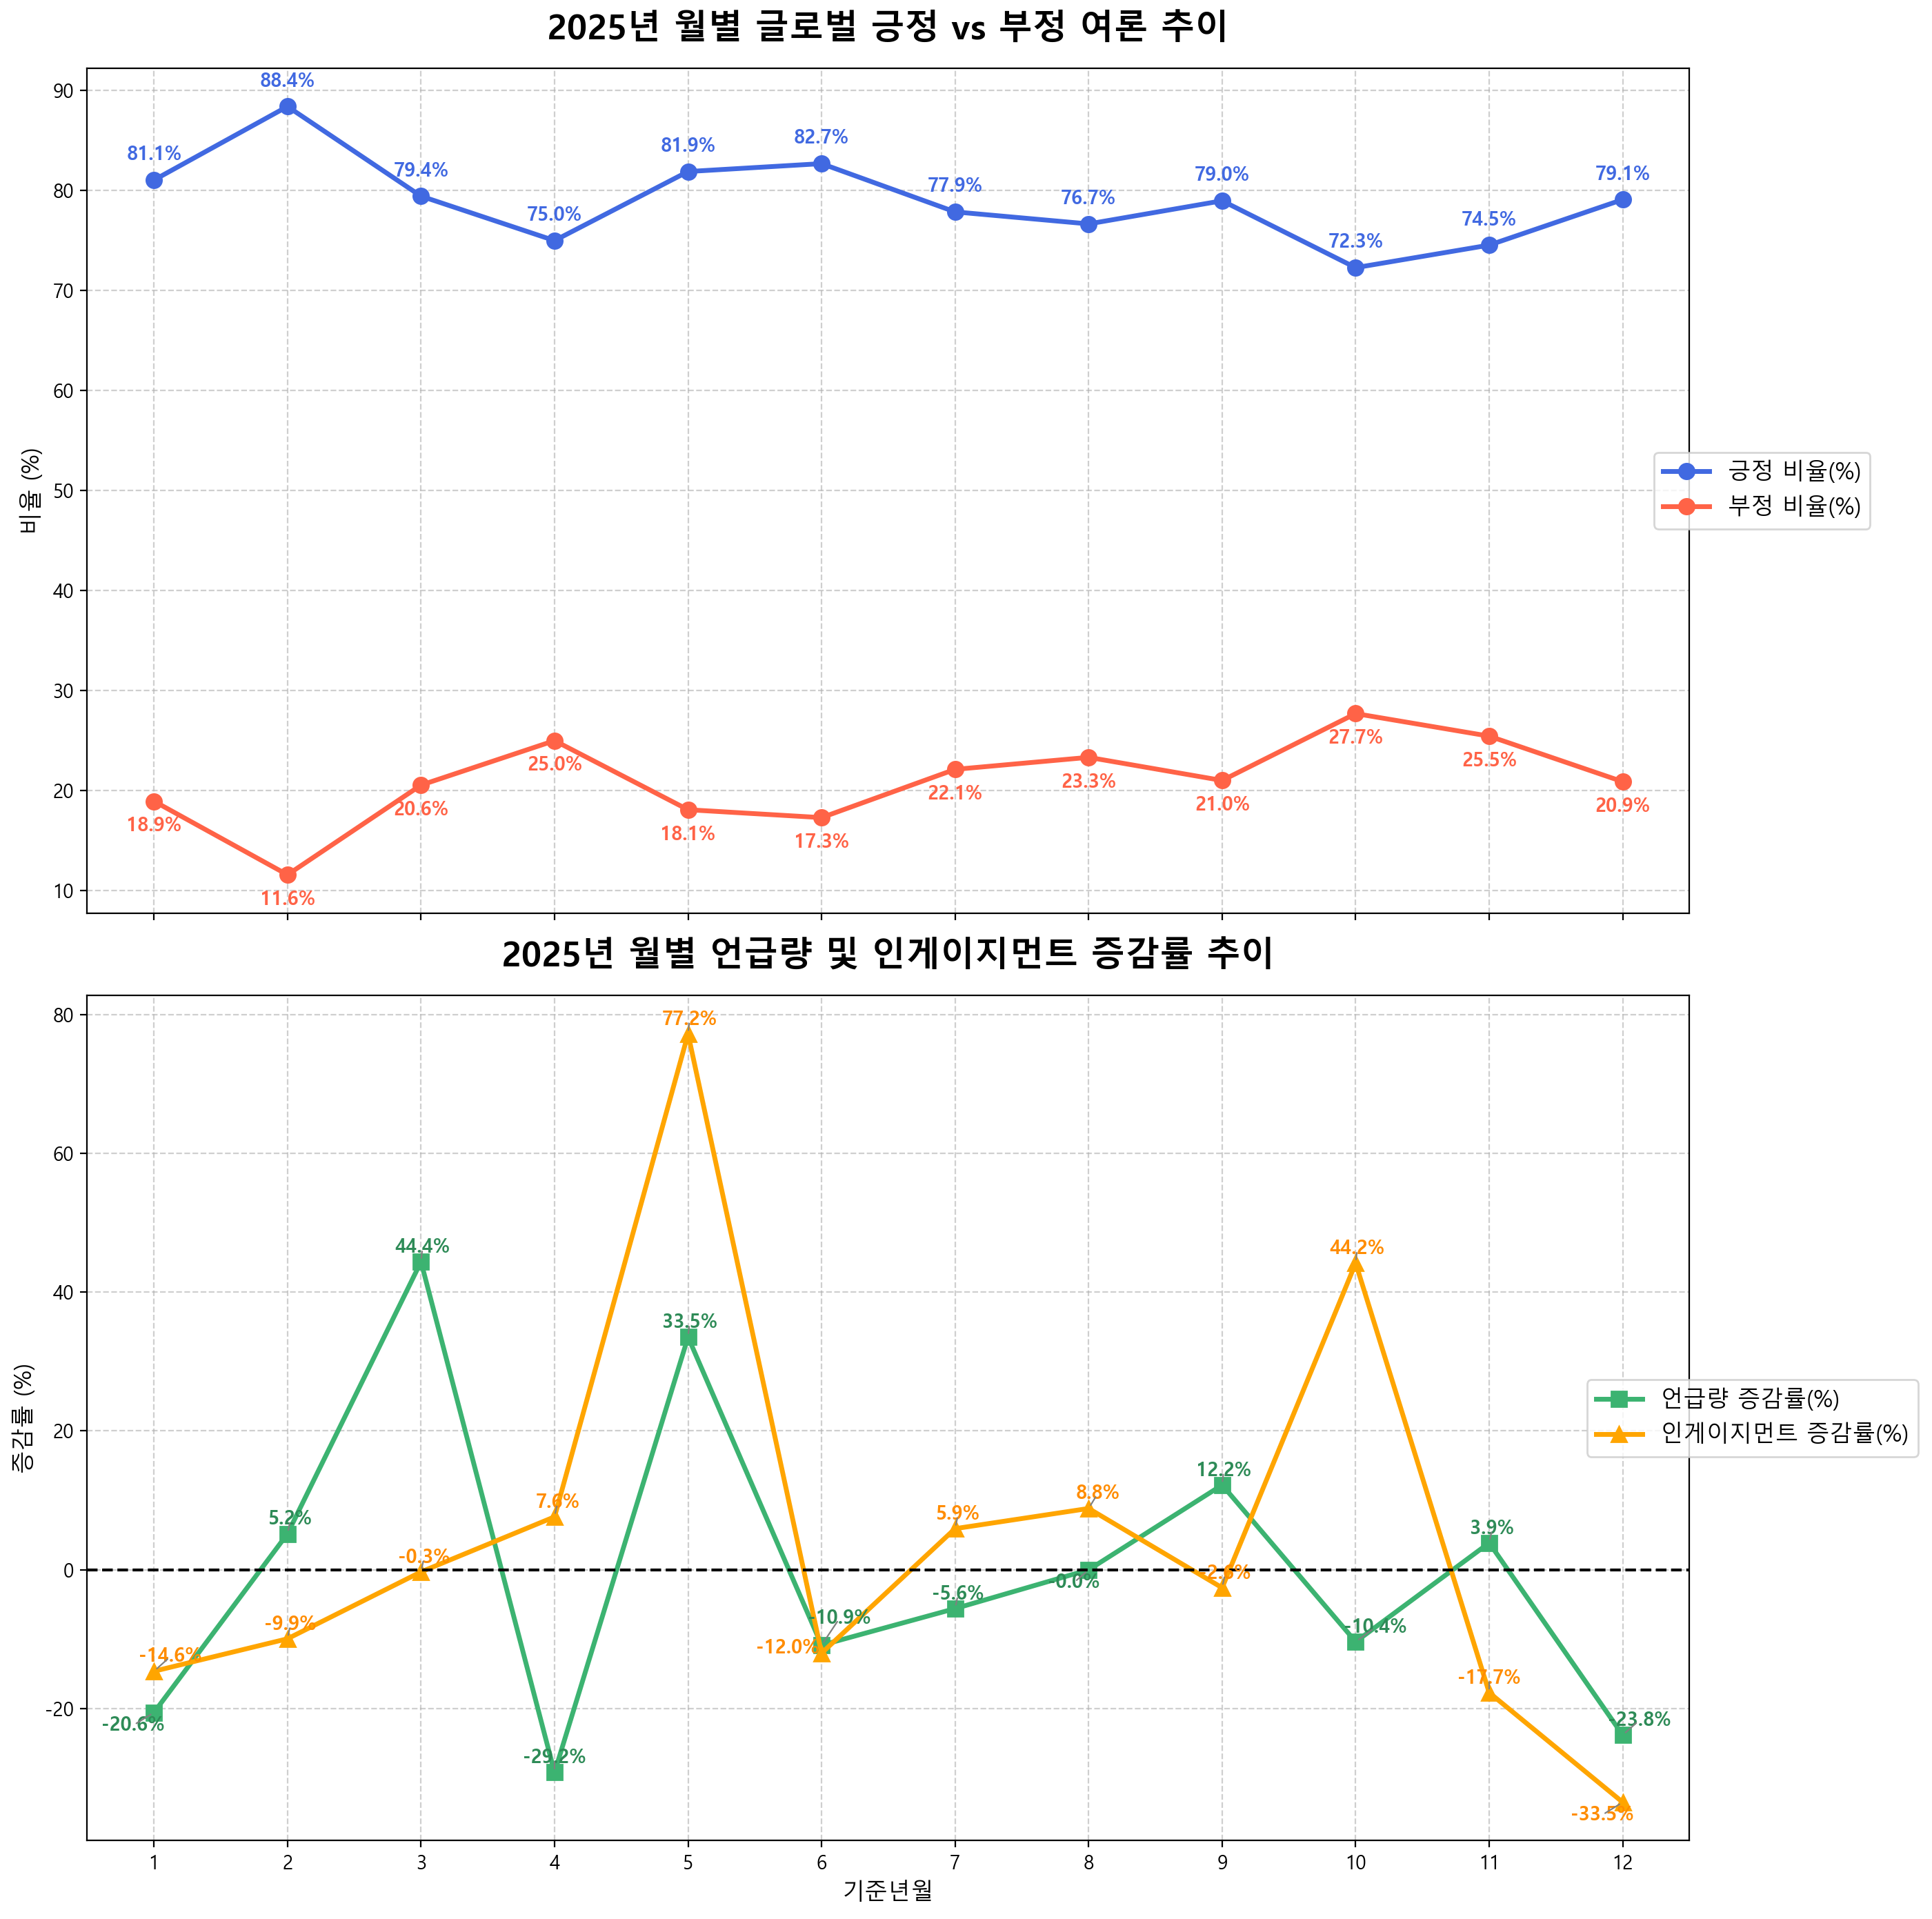

In [11]:
# 불필요한 경고 메시지 숨기기
warnings.filterwarnings('ignore') 

# X축 기준년월 문자열 생성
mention['기준년월_str'] = mention['기준년월'].astype(str).str[2:4] + "년 " + mention['기준년월'].astype(str).str[4:] + "월"

x_pos = range(len(mention))

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# [그래프 1] 긍정 vs 부정 여론 비율 추이
# x_pos 숫자 좌표로 그래프 그리기
axes[0].plot(x_pos, mention['긍정언급량 비율'], marker='o', color='royalblue', linewidth=2.5, markersize=8, label='긍정 비율(%)')
axes[0].plot(x_pos, mention['부정언급량 비율'], marker='o', color='tomato', linewidth=2.5, markersize=8, label='부정 비율(%)')

for i in range(len(mention)):
    axes[0].text(i, mention['긍정언급량 비율'].iloc[i] + 1.5, f"{mention['긍정언급량 비율'].iloc[i]:.1f}%", ha='center', va='bottom', fontsize=10, color='royalblue', fontweight='bold')
    axes[0].text(i, mention['부정언급량 비율'].iloc[i] - 1.5, f"{mention['부정언급량 비율'].iloc[i]:.1f}%", ha='center', va='top', fontsize=10, color='tomato', fontweight='bold')

axes[0].set_title('2025년 월별 글로벌 긍정 vs 부정 여론 추이', fontsize=18, fontweight='bold', pad=15)
axes[0].set_ylabel('비율 (%)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=12, loc='center right', bbox_to_anchor=(1.12, 0.5))

# 여백 확보 및 위쪽 그래프 X축 라벨 숨기기
axes[0].set_xlim(-0.5, len(mention) - 0.5)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([]) # 위쪽 그래프는 X축 글씨 숨김

# [그래프 2] 언급량 및 인게이지먼트 증감률 추이
# x_pos 숫자 좌표로 그래프 그리기
axes[1].plot(x_pos, mention['언급량 증감률'], marker='s', color='mediumseagreen', linewidth=2.5, markersize=8, label='언급량 증감률(%)')
axes[1].plot(x_pos, mention['인게이지먼트 증감률'], marker='^', color='orange', linewidth=2.5, markersize=8, label='인게이지먼트 증감률(%)')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')

texts = []
for i in range(len(mention)):
    t1 = axes[1].text(i, mention['언급량 증감률'].iloc[i], 
                      f"{mention['언급량 증감률'].iloc[i]:.1f}%", 
                      ha='center', fontsize=10, color='seagreen', fontweight='bold')
    texts.append(t1)
    
    t2 = axes[1].text(i, mention['인게이지먼트 증감률'].iloc[i], 
                      f"{mention['인게이지먼트 증감률'].iloc[i]:.1f}%", 
                      ha='center', fontsize=10, color='darkorange', fontweight='bold')
    texts.append(t2)

# adjust_text 실행 (텍스트 겹침 방지)
adjust_text(texts, ax=axes[1], 
            arrowprops=dict(arrowstyle='-', color='grey', lw=0.8),
            expand_points=(1.5, 1.5))

axes[1].set_title('2025년 월별 언급량 및 인게이지먼트 증감률 추이', fontsize=18, fontweight='bold', pad=15)
axes[1].set_ylabel('증감률 (%)', fontsize=12)
axes[1].set_xlabel('기준년월', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=12, loc='center right', bbox_to_anchor=(1.15, 0.5))

# 여백 확보 및 아래쪽 그래프 X축 라벨 덮어쓰기
axes[1].set_xlim(-0.5, len(mention) - 0.5)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(mention['월']) 

plt.tight_layout()
plt.show()

## 언급량 인게이지먼트 잠재적 노출량

In [12]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "완전최종_전처리완료_CSV모음")  # 가공 데이터 저장 폴더

DATA_DIR = os.path.join(FOLDER_DIR, "한국관광관련_국가별_언급량_인게이지먼트_잠재적_노출량.csv")

mention2 = pd.read_csv(DATA_DIR)

mention2

,국가,언급량,인게이지먼트,잠재적 노출량
0,일본,2581487,31263620,21052270221
1,필리핀,307587,2095946,24910856209
2,미국,842913,15270347,5396993551
3,캐나다,87906,1065355,1236779504
4,독일,204874,2167619,960306199
5,프랑스,228548,4691714,2418021775
6,영국,136394,1755088,2091379529
7,러시아,91535,1903726,216228818
8,아랍에미리트,59509,679416,586057555
9,인도,185129,8893531,2746259593


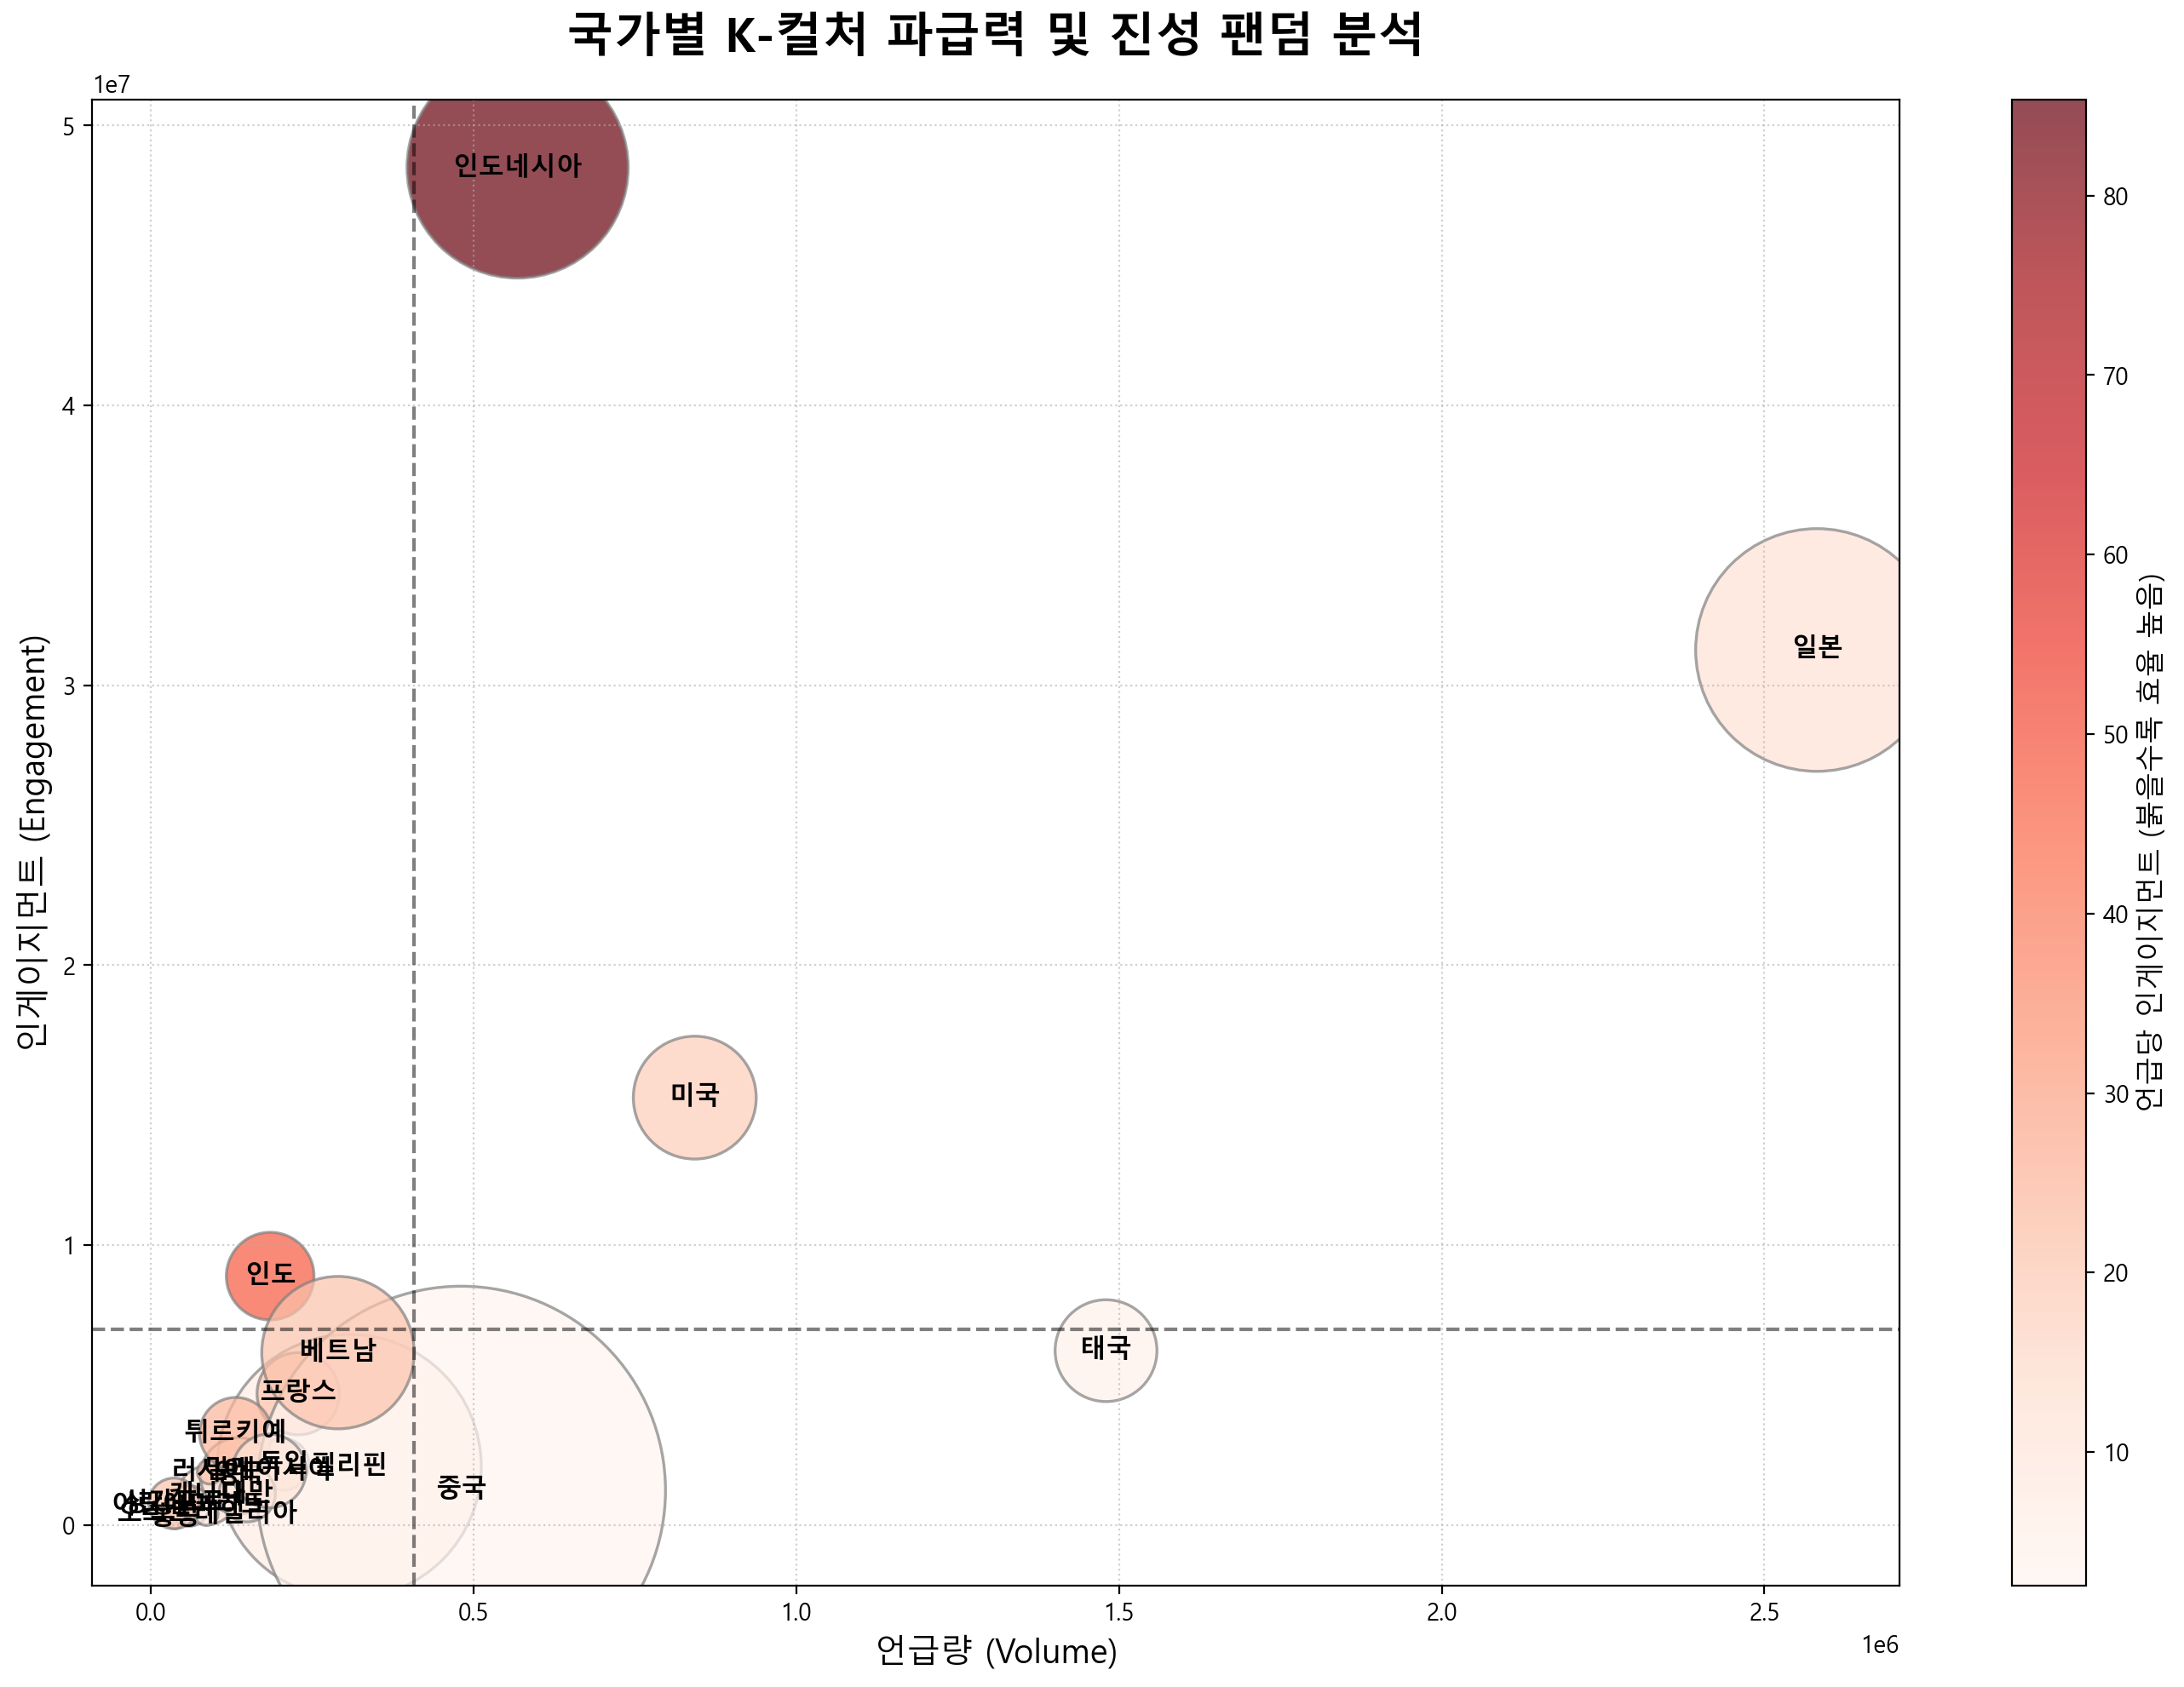

In [13]:
# 파생 변수 생성: '언급당 인게이지먼트' (글 1개를 쓸 때 얼마나 많은 호응을 이끌어내는가?)
mention2['언급당_인게이지먼트'] = mention2['인게이지먼트'] / mention2['언급량']

plt.figure(figsize=(14, 10))

# 버블 크기 스케일링 
bubble_sizes = mention2['잠재적 노출량'] / 2000000

# 산점도 그리기
scatter = plt.scatter(x=mention2['언급량'], 
                      y=mention2['인게이지먼트'], 
                      s=bubble_sizes, 
                      c=mention2['언급당_인게이지먼트'], # 색상: 붉은색일수록 진성 팬(효율 최고!)
                      cmap='Reds', # 하얀색 -> 붉은색 그라데이션
                      alpha=0.7, 
                      edgecolors='grey', 
                      linewidth=1.2)

# 버블 중앙에 국가명 텍스트 라벨 달기
for i in range(len(mention2)):
    plt.text(mention2['언급량'].iloc[i], 
             mention2['인게이지먼트'].iloc[i], 
             mention2['국가'].iloc[i], 
             fontsize=11, 
             ha='center', 
             va='center', 
             fontweight='bold')

# 평균 십자선 추가
plt.axvline(mention2['언급량'].mean(), color='black', linestyle='--', alpha=0.5)
plt.axhline(mention2['인게이지먼트'].mean(), color='black', linestyle='--', alpha=0.5)

# 그래프 꾸미기
plt.title('국가별 K-컬처 파급력 및 진성 팬덤 분석', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('언급량 (Volume)', fontsize=14)
plt.ylabel('인게이지먼트 (Engagement)', fontsize=14)

# 범례 추가
cbar = plt.colorbar(scatter)
cbar.set_label('언급당 인게이지먼트 (붉을수록 효율 높음)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

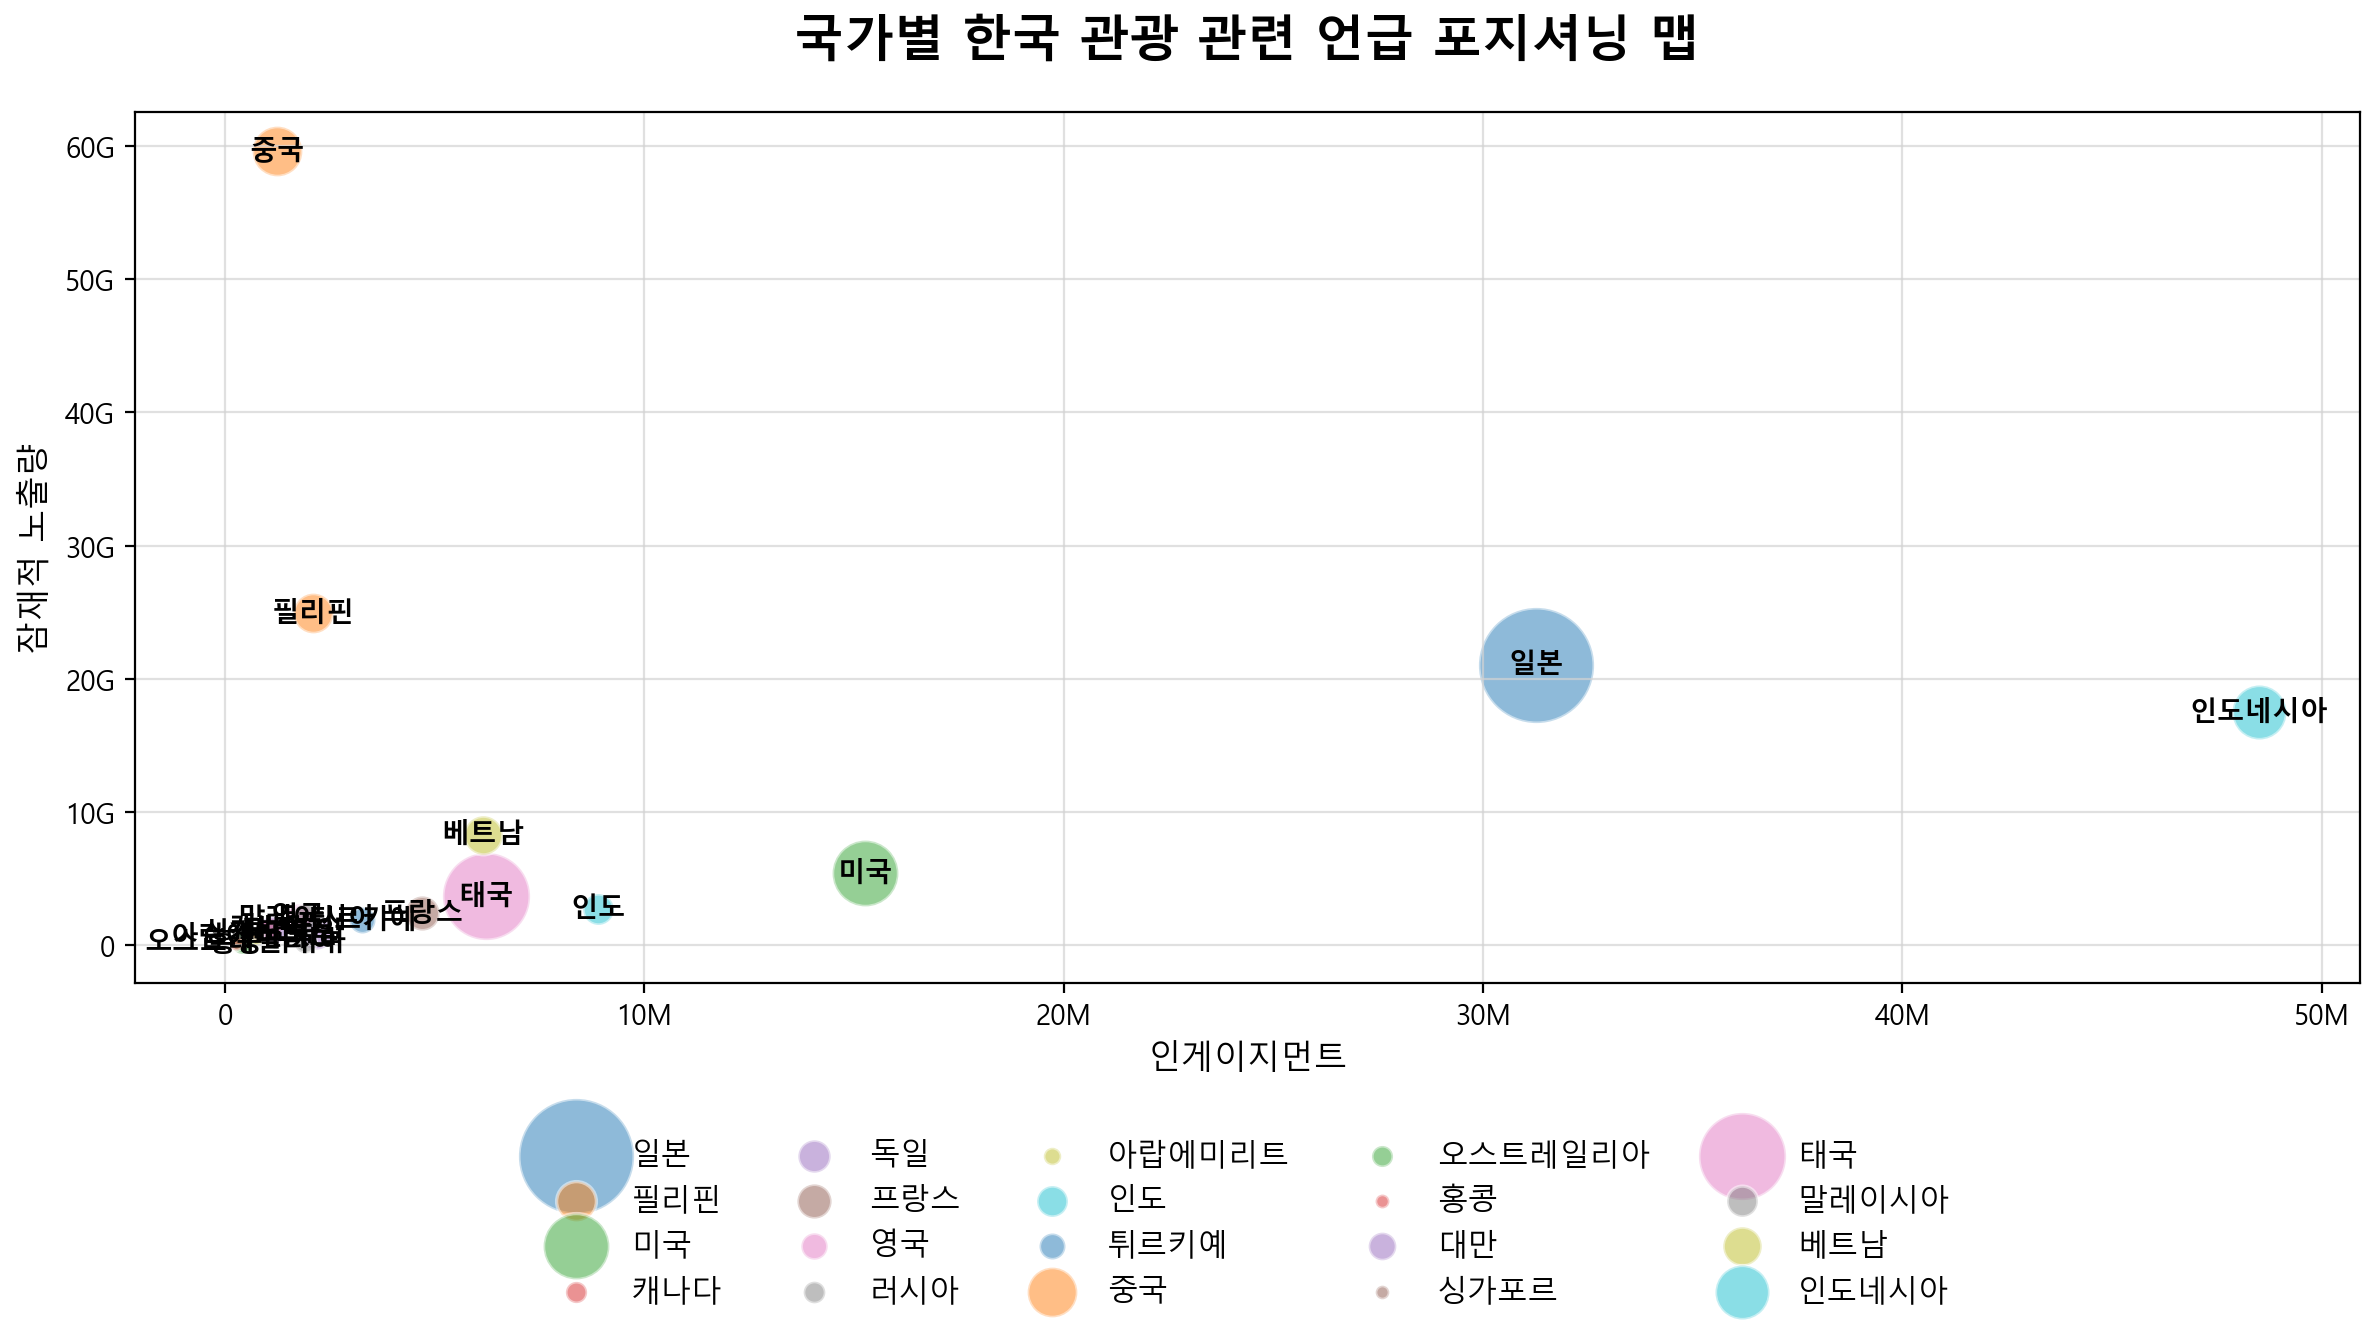

In [14]:
plt.figure(figsize=(12, 7))

# 버블 크기 조절용 스케일 팩터
scale_factor = 1500 

# 각 국가별로 점(버블) 찍기 및 텍스트 추가
for idx, row in mention2.iterrows():
    # 🔴 버블 그리기
    plt.scatter(x=row['인게이지먼트'], 
                y=row['잠재적 노출량'], 
                s=row['언급량'] / scale_factor, 
                alpha=0.5, 
                edgecolors='white', 
                linewidth=1.2,
                label=row['국가']) # 하단 범례용 라벨
    
    # 버블 중앙에 국가명 텍스트 달기
    plt.text(x=row['인게이지먼트'], 
             y=row['잠재적 노출량'], 
             s=row['국가'], 
             fontsize=10, 
             ha='center', 
             va='center', 
             fontweight='bold',
             color='black')

# 축 눈금 단위 포맷팅
def format_x(x, pos):
    if x == 0: return '0'
    return f'{int(x / 1000000)}M'

def format_y(y, pos):
    if y == 0: return '0'
    return f'{int(y / 1000000000)}G'

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_x))
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y))

# 타이틀과 축 라벨 설정
plt.title('국가별 한국 관광 관련 언급 포지셔닝 맵', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('인게이지먼트', fontsize=12)
plt.ylabel('잠재적 노출량', fontsize=12)

# 배경 그리드(격자) 켜기
plt.grid(True, linestyle='-', color='lightgrey', alpha=0.7)

# 범례(Legend) 설정
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=5, frameon=False, fontsize=11, scatterpoints=1)

plt.tight_layout()
plt.show()